# Title: Internshala Internship Data Analysis

## Problem Statement

This project scrapes internship data from Internshala to identify patterns that support better career decisions.

**Website:**  Internshala

**Website Link:** https://internshala.com/internships

**Method:** Web Scraping using BeautifulSoup

**Target feature:** stipend - factors affecting internship pay.

**Supporting features:**
- **location** — does city affect stipend?
- **duration_months** — do longer internships pay more?
- **skills_required** — do certain skills lead to higher pay?
- **actively_hiring** — do urgent listings offer better stipend?
- **internship_title** — which roles pay the most?
- **company_name** — which companies pay the most?
- **posted_time** — do recently posted internships pay differently?
- **is_it** — is the job role IT-based or not?

### Loading required libraries

In [1]:
import requests                 # sends HTTP requests to websites
from bs4 import BeautifulSoup   # parses and navigates HTML

import pandas as pd             # data manipulation and dataframes
import numpy as np              # numerical operations

import re                       # regular expressions for text cleaning
import time                     # adds delays between requests

import matplotlib.pyplot as plt  # data visualization
import seaborn as sns            # statistical data visualization

## Web Scraping

### 1. Getting webpage content

In [2]:
url = "https://internshala.com/internships/page-1/"   # target page
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0;Win64; x64; rv:106.0) Gecko/20100101 Firefox/106.0'}   # mimics browser to avoid bot detection
response = requests.get(url, headers=headers, timeout=10)   # sends request, stops if no response in 10 seconds
print(response.status_code)   # 200 = success

200


### 2. Parsing HTML

In [3]:
soup = BeautifulSoup(response.text, "html.parser")   # structures raw HTML for easy navigation
print(soup.prettify()[:2000])                        # prettify formats HTML with indents, previewing first 2000 characters

<!DOCTYPE html>
<html lang="en-US" xmlns="http://www.w3.org/1999/xhtml" xmlns:fb="https://www.facebook.com/2008/fbml" xmlns:og="http://ogp.me/ns#">
 <head>
  <meta content="IE=9" http-equiv="X-UA-Compatible"/>
  <meta charset="utf-8"/>
  <meta content="width=device-width, initial-scale=1.0 user-scalable=0" name="viewport"/>
  <meta content="702141670710132" property="fb:app_id"/>
  <meta content="website" property="og:type"/>
  <meta content="1200" property="og:image:width"/>
  <meta content="630" property="og:image:height"/>
  <link as="image" href="https://internshala.com//static/images/home/sprites/img-assets.png" rel="preload"/>
  <link as="image" href="https://internshala.com/static/images/internship/banners/jobs_banner_r767.png" media="(max-width: 767px)" rel="preload"/>
  <link as="image" href="https://internshala.com/static/images/internship/banners/jobs_banner_r1920.png" media="(min-width: 767.1px)" rel="preload"/>
  <link as="image" href="https://internshala.com/static/images

### 3. Finding Internship Cards

In [4]:
cards = soup.find_all("div", class_="individual_internship")  # finds all internship cards(postings) on the page
print(len(cards))                                             # total number of internship cards found

51


**Observations:**
- Each card represents an Internship posting
- Each internship is contained within a div with class "individual_internship"
- Total cards per page are consistent (~50), meaning pagination is required to collect full dataset
- Data is structured uniformly, which makes large-scale extraction feasible

### 4. Understanding the Data Structure

In [5]:
# checking raw HTML of first card/job
print(cards[0].prettify())

<div class="container-fluid individual_internship view_detail_button visibilityTrackerItem" data-href="/internship/detail/recruitment-consultant-internship-in-gurgaon-at-p-m1773464397" data-source_page="search_page" employment_type="internship" id="individual_internship_3080307" internshipid="3080307" sequential_apply_referral="similar_internships">
 <div class="internship_meta duration_meta">
  <div class="internship-heading-container">
   <div class="company">
    <h2 class="job-internship-name">
     <a class="job-title-href" href="/internship/detail/recruitment-consultant-internship-in-gurgaon-at-p-m1773464397" id="job_title" target="_blank">
      Recruitment Consultant
     </a>
    </h2>
    <div class="heading_6 company_name">
     <div class="company_and_premium">
      <p class="company-name">
       P&amp;M
      </p>
      <div class="actively-hiring-badge">
       Actively hiring
      </div>
     </div>
    </div>
   </div>
   <div class="internship_logo">
    <img alt="P

In [6]:
# pulling each field from first card to test
card = cards[0]

title    = card.find("h2", class_="job-internship-name").text.strip()        # internship role name
company  = card.find("p", class_="company-name").text.strip()                # company offering the internship
location = card.find("div", class_="locations").text.strip()                 # location of the internship
stipend  = card.find("span", class_="stipend").text.strip()                  # pay range in ₹
duration = card.find("i", class_="ic-16-calendar").find_next_sibling("span").text.strip()  # length of internship
active   = bool(card.find("div", class_="actively-hiring-badge"))            # True if actively hiring badge exists
skills   = [s.text.strip() for s in card.find_all("div", class_="job_skill")]  # list of required skills

# checking if internship is IT related based on keywords in title
it_keywords = ["developer", "engineer", "data", "ai", "software", "python", "web", "coding", "programmer", "tech", "machine learning", "cyber", "cloud", "database", "ml", "analyst"]
is_it = any(keyword in title.lower() for keyword in it_keywords)             # True if any IT keyword found in title

print("Title:", title)
print("Company:", company)
print("Location:", location)
print("Stipend:", stipend)
print("Duration:", duration)
print("Actively Hiring:", active)
print("Skills:", skills)
print("Is IT:", is_it)

Title: Recruitment Consultant
Company: P&M
Location: Gurgaon
Stipend: ₹ 8,000 - 10,000 /month
Duration: 6 Months
Actively Hiring: True
Skills: ['Client Relationship', 'English Proficiency (Spoken)', 'English Proficiency (Written)']
Is IT: False


**Observations:**
- Key fields like title, company, location, stipend, duration are consistently present across cards
- Some fields (like posted_time) are inconsistently available
- Data is semi-structured → requires conditional extraction (handling missing elements)

In [7]:
# checking posted time field across all cards on page 1
for i, card in enumerate(cards):
    ab = card.find("div", class_="status-success")
    print(f"Card {i}:", ab.text.strip() if ab else "Not found")

Card 0: Not found
Card 1: Few hours ago
Card 2: Today
Card 3: 1 day ago
Card 4: 2 days ago
Card 5: Not found
Card 6: Just now
Card 7: Today
Card 8: 1 day ago
Card 9: 1 day ago
Card 10: Not found
Card 11: 1 day ago
Card 12: Today
Card 13: Today
Card 14: 1 day ago
Card 15: 1 day ago
Card 16: 1 day ago
Card 17: 1 day ago
Card 18: 1 day ago
Card 19: 2 days ago
Card 20: 2 days ago
Card 21: 2 days ago
Card 22: Not found
Card 23: Not found
Card 24: 1 day ago
Card 25: 1 day ago
Card 26: 1 day ago
Card 27: 2 days ago
Card 28: 2 days ago
Card 29: 2 days ago
Card 30: Not found
Card 31: Not found
Card 32: Not found
Card 33: Not found
Card 34: Not found
Card 35: Not found
Card 36: Not found
Card 37: Not found
Card 38: Not found
Card 39: Not found
Card 40: Not found
Card 41: Not found
Card 42: Not found
Card 43: Not found
Card 44: Not found
Card 45: Not found
Card 46: Not found
Card 47: Not found
Card 48: Not found
Card 49: Not found
Card 50: Not found


**Observations:**
- posted_time is missing in a large number of cards
- Indicates either inconsistent HTML structure or optional field by the platform
- This column may not be reliable for analysis

### 5. Extracting Data from All Cards

In [8]:
# collecting all fields from every card on page 1
data = []

# keywords to identify IT related internships
it_keywords = ["developer", "engineer", "data", "ai", "software", "python", "web", "coding", "programmer", "tech", "machine learning", "cyber", "cloud", "database", "ml", "analyst"]

for card in cards:
    title = card.find("h2", class_="job-internship-name")          # internship role name
    company = card.find("p", class_="company-name")                # company offering the internship
    location = card.find("div", class_="locations")                # location of the internship
    stipend = card.find("span", class_="stipend")                  # pay range in ₹
    duration = card.find("i", class_="ic-16-calendar")             # length of internship
    active = bool(card.find("div", class_="actively-hiring-badge"))  # True if actively hiring badge exists
    skills = [s.text.strip() for s in card.find_all("div", class_="job_skill")]  # list of required skills
    posted = card.find("div", class_="status-success")             # how recently posted

    if not title:        # skip ad cards that have no title
        continue

    title_text = title.text.strip()
    is_it = any(keyword in title_text.lower() for keyword in it_keywords)  # True if IT related role

    data.append({
        "internship_title": title_text,
        "company_name": company.text.strip() if company else np.nan,
        "location": location.text.strip() if location else np.nan,
        "stipend_per_month": stipend.text.strip() if stipend else np.nan,
        "duration_months": duration.find_next_sibling("span").text.strip() if duration else np.nan,
        "actively_hiring": active,
        "skills_required": ", ".join(skills) if skills else np.nan,
        "posted_time": posted.text.strip() if posted else np.nan,
        "is_it": is_it                                             # True if IT role, False if non-IT
    })

print(f"extracted {len(data)} internships from page 1")

extracted 50 internships from page 1


**Observations:**
- Introduced keyword-based filtering to identify IT-related internships
- This adds domain focus but may include some false positives/negatives depending on keyword coverage

### 6. Scraping All 130 Pages

In [9]:
# extracting data across all 130 pages
all_data = []   # empty list to store all internship data

# keywords to identify IT related internships
it_keywords = ["developer", "engineer", "data", "ai", "software", "python", "web", "coding", "programmer", "tech", "machine learning", "cyber", "cloud", "database", "ml", "analyst"]

for page in range(1, 131):
    url = f"https://internshala.com/internships/page-{page}/"
    response = requests.get(url, headers=headers, timeout=10)

    if response.status_code != 200:             # 200 means success, skip if failed
        print(f"page {page} failed, skipping")
        continue

    soup = BeautifulSoup(response.text)
    cards = soup.find_all("div", class_="individual_internship")   # all internship cards on this page

    for card in cards:
        title = card.find("h2", class_="job-internship-name")
        company = card.find("p", class_="company-name")
        location = card.find("div", class_="locations")
        stipend = card.find("span", class_="stipend")
        duration = card.find("i", class_="ic-16-calendar")
        active = bool(card.find("div", class_="actively-hiring-badge"))
        skills = [s.text.strip() for s in card.find_all("div", class_="job_skill")]
        posted = card.find("div", class_="status-success")

        if not title:    # skip ad cards with no title
            continue

        title_text = title.text.strip()
        is_it = any(keyword in title_text.lower() for keyword in it_keywords)  # True if IT related role

        all_data.append({
            "internship_title": title_text,
            "company_name": company.text.strip() if company else np.nan,
            "location": location.text.strip() if location else np.nan,
            "stipend_per_month": stipend.text.strip() if stipend else np.nan,
            "duration_months": duration.find_next_sibling("span").text.strip() if duration else np.nan,
            "actively_hiring": active,
            "skills_required": ", ".join(skills) if skills else np.nan,
            "posted_time": posted.text.strip() if posted else np.nan,
            "is_it": is_it                                          # True if IT role, False if non-IT
        })

    print(f"page {page} done | {len(all_data)} rows")    # shows progress while scraping 130 pages
    time.sleep(1.5)   # delay between requests to avoid getting blocked

print(f"total rows collected: {len(all_data)}")

page 1 done | 50 rows
page 2 done | 90 rows
page 3 done | 130 rows
page 4 done | 170 rows
page 5 done | 210 rows
page 6 done | 250 rows
page 7 done | 290 rows
page 8 done | 330 rows
page 9 done | 370 rows
page 10 done | 410 rows
page 11 done | 450 rows
page 12 done | 490 rows
page 13 done | 530 rows
page 14 done | 570 rows
page 15 done | 610 rows
page 16 done | 650 rows
page 17 done | 690 rows
page 18 done | 730 rows
page 19 done | 770 rows
page 20 done | 810 rows
page 21 done | 850 rows
page 22 done | 890 rows
page 23 done | 930 rows
page 24 done | 970 rows
page 25 done | 1010 rows
page 26 done | 1050 rows
page 27 done | 1090 rows
page 28 done | 1130 rows
page 29 done | 1170 rows
page 30 done | 1210 rows
page 31 done | 1250 rows
page 32 done | 1290 rows
page 33 done | 1330 rows
page 34 done | 1370 rows
page 35 done | 1410 rows
page 36 done | 1450 rows
page 37 done | 1490 rows
page 38 done | 1530 rows
page 39 done | 1570 rows
page 40 done | 1610 rows
page 41 done | 1650 rows
page 42 do

**Observations:**
- Pagination handled using loop across 130 pages to scale data collection
- Ensures dataset is not biased to a single page snapshot
- However, scraping large volumes may be affected by request limits or site changes

### 7. Building the Dataframe & Saving as CSV

In [10]:
# converting collected list of dicts into a dataframe
df = pd.DataFrame(all_data)

# saving dataset to csv file
df.to_csv("internshala.csv", index=False)   # index=False avoids saving row numbers as a column
print(f"{df.shape[0]} rows, {df.shape[1]} columns")   # confirm shape

5210 rows, 9 columns


**Observations:**
- Successfully structured scraped data into tabular format
- Dataset is now ready for cleaning and analysis
- Initial structure depends heavily on scraping accuracy and consistency

## Data Cleaning

### 1. Loading the Dataset & Observation

In [11]:
# loading dataset from saved csv file
df = pd.read_csv("internshala.csv")   # reading the saved csv
df.head()                              # preview first 5 rows

,internship_title,company_name,location,stipend_per_month,duration_months,actively_hiring,skills_required,posted_time,is_it
0,Recruitment Consultant,P&M,Gurgaon,"₹ 8,000 - 10,000 /month",6 Months,True,"Client Relationship, English Proficiency (Spok...",NaN,False
1,Inside Sales Intern – E-Commerce (Seller Onboa...,HiWi Forex Services Limited,Mumbai ...,"₹ 5,000 - 5,001 /month",3 Months,True,"Interpersonal skills, Effective Communication",Few hours ago,False
2,Video Editing/Making,Orvador,Mohali,"₹ 8,000 - 10,000 /month",3 Weeks,True,"Adobe Photoshop, Adobe Illustrator, Video Edit...",Today,False
3,Sales,RUCHIRA SINGH,Bangalore ...,"₹ 10,000 - 20,000 /month",3 Months,True,"Client Interaction, Decision making, Client Re...",1 day ago,False
4,Architecture,Node Urban Lab,Lucknow,"₹ 8,000 /month",6 Months,True,"AutoCAD, Adobe Photoshop, Adobe Illustrator, G...",2 days ago,False


In [12]:
df.tail()                              # preview last 5 rows

,internship_title,company_name,location,stipend_per_month,duration_months,actively_hiring,skills_required,posted_time,is_it
5205,Sales Operations – Data Cleansing & Enrichment,Tvarana Software Solutions Private Limited,Hyderabad,"₹ 15,000 - 16,000 /month",6 Months,True,"MS-Office, Data Analytics, MS-Excel, Data Clea...",NaN,True
5206,Product Operations,Health Click Away,Gurgaon,"₹ 10,000 - 15,000 /month",3 Months,True,"Analytical Thinking, Effective Communication, ...",NaN,False
5207,IT & Web Development,K NET KING,Jaipur,"₹ 3,000 - 5,000 /month",6 Months,False,"JavaScript, Project Management, Web developmen...",NaN,True
5208,WordPress Development,Foonix,Work from home,"₹ 5,000 - 10,000 /month",6 Months,True,"PHP, HTML, CSS, JavaScript, WordPress, Search ...",NaN,False
5209,Instagram Growth Manager,KaroStartup,Work from home,"₹ 13,000 - 20,000 /month",3 Months,True,"Creative Thinking, Creative Writing, Entrepren...",NaN,False


In [13]:
df.shape         # no.of rows and columns

(5210, 9)

In [14]:
df.columns         # column Names

Index(['internship_title', 'company_name', 'location', 'stipend_per_month',
       'duration_months', 'actively_hiring', 'skills_required', 'posted_time',
       'is_it'],
      dtype='object')

In [15]:
df.dtypes        # data type of each column

,0
internship_title,object
company_name,object
location,object
stipend_per_month,object
duration_months,object
actively_hiring,bool
skills_required,object
posted_time,object
is_it,bool


In [16]:
df.describe()      # Statistical summary

,internship_title,company_name,location,stipend_per_month,duration_months,actively_hiring,skills_required,posted_time,is_it
count,5210,5210,5210,5209,5210,5210,5051,1215,5210
unique,1519,3918,546,737,16,2,3758,5,2
top,Business Development (Sales),Conversely,Work from home,"₹ 5,000 - 10,000 /month",3 Months,False,Effective Communication,1 day ago,False
freq,478,39,1243,262,1984,3042,71,416,4731


In [17]:
df.info()                 # data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5210 entries, 0 to 5209
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   internship_title   5210 non-null   object
 1   company_name       5210 non-null   object
 2   location           5210 non-null   object
 3   stipend_per_month  5209 non-null   object
 4   duration_months    5210 non-null   object
 5   actively_hiring    5210 non-null   bool  
 6   skills_required    5051 non-null   object
 7   posted_time        1215 non-null   object
 8   is_it              5210 non-null   bool  
dtypes: bool(2), object(7)
memory usage: 295.2+ KB


In [18]:
df.isnull().sum() # missing values per column

,0
internship_title,0
company_name,0
location,0
stipend_per_month,1
duration_months,0
actively_hiring,0
skills_required,159
posted_time,3995
is_it,0


**Observations:**
- Dataset contains 5210 rows and 9 columns
- stipend_per_month has only 1 missing value → safe to drop
- skills_required has moderate missing values (159) → can be imputed
- posted_time has excessive missing values (~75%) → not reliable for analysis
- stipend_per_month and duration_months are stored as strings → require type conversion for numerical analysis

### 2. Missing Value Treatment

In [19]:
# dropping row where stipend is missing
df = df.dropna(subset=["stipend_per_month"])

# filling missing skills with Not Specified
df["skills_required"] = df["skills_required"].fillna("Not Specified")

# dropping posted_time column, too many missing values
df = df.drop(columns=["posted_time"])

# Rechecking the shape after handling missing values
print(df.shape)

(5209, 8)


In [20]:
# Rechecking if DataFrame still has any Null values
print(df.isnull().sum())

internship_title     0
company_name         0
location             0
stipend_per_month    0
duration_months      0
actively_hiring      0
skills_required      0
is_it                0
dtype: int64


**Observations:**
- dropped 1 row with missing stipend
- filled 159 missing skills with "Not Specified"
- dropped posted_time — 3995 out of 5210 values were missing, not useful

### 3. Duplicate Handling

In [21]:
# checking for duplicate rows
print(df.duplicated().sum())   # total number of duplicate rows found

32


In [22]:
# removing all duplicate rows
df = df.drop_duplicates()
print(df.shape)                # confirm rows after duplicates removed

(5177, 8)


**Observations:**
- found 32 duplicate rows
- removed all duplicates
- dataset now has 5177 rows and 8 columns

### Feature Engineering

In [23]:
# extracting minimum and maximum stipend from range like ₹ 10,000 - 20,000 /month
def extract_stipend(value):
    numbers = re.findall(r'\d+,?\d+', str(value))                  # find all numbers in string
    numbers = [int(n.replace(',', '')) for n in numbers]           # remove commas, convert to int
    if len(numbers) == 2:
        return numbers[0], numbers[1]                              # return min and max
    elif len(numbers) == 1:
        return numbers[0], numbers[0]                              # same value for both if single number
    else:
        return np.nan, np.nan                                      # no number found

# applying function and creating two separate columns
df["stipend_min"], df["stipend_max"] = zip(*df["stipend_per_month"].apply(extract_stipend))

print(df[["stipend_min", "stipend_max"]].head(10))
print(df["stipend_min"].dtype, df["stipend_max"].dtype)

   stipend_min  stipend_max
0       8000.0      10000.0
1       5000.0       5001.0
2       8000.0      10000.0
3      10000.0      20000.0
4       8000.0       8000.0
5       5000.0       5000.0
6       4500.0       5000.0
7      11000.0      18000.0
8       8000.0      10000.0
9      10000.0      20000.0
float64 float64


In [24]:
# converting all durations to weeks
def clean_duration(value):
    value = str(value).lower()                        # lowercase for easy matching
    number = re.findall(r'\d+', value)                # extracting the duration
    if not number:
        return np.nan                                 # duration not found
    number = int(number[0])
    if 'month' in value:
        return number * 4                             # convert months to weeks
    elif 'week' in value:
        return number                                 # already in weeks
    else:
        return np.nan

df["duration_weeks"] = df["duration_months"].apply(clean_duration)   # apply to column
print(df["duration_weeks"].value_counts())    # Checking number of internship posting for each count of Duration in weeks

duration_weeks
12     1962
24     1960
8       474
4       299
16      288
20       49
2        39
96       38
1        36
3        16
6         9
48        5
5         1
144       1
Name: count, dtype: int64


In [25]:
# Checking the Datatype of new column duration_weeks
print(df["duration_weeks"].dtype)

int64


In [26]:
# dropping original text columns, keeping cleaned versions
df = df.drop(columns=["stipend_per_month", "duration_months"])
print(df.columns.tolist())    # confirm remaining columns

['internship_title', 'company_name', 'location', 'actively_hiring', 'skills_required', 'is_it', 'stipend_min', 'stipend_max', 'duration_weeks']


**Observations:**
- Extracted numerical stipend ranges (min & max) from text format
- Converted duration into a standardized unit (weeks) for consistency
- Feature engineering enables meaningful numerical and comparative analysis

### 4. Outlier Detection & Treatment

In [27]:
# statistical summary of numerical columns
print(df[["stipend_min", "stipend_max", "duration_weeks"]].describe())

        stipend_min   stipend_max  duration_weeks
count   4855.000000   4855.000000     5177.000000
mean    8093.120082  12979.860968       16.498551
std     5155.717549   8496.528013        9.964138
min       50.000000      0.000000        1.000000
25%     5000.000000   8000.000000       12.000000
50%     7000.000000  10002.000000       12.000000
75%    10000.000000  15000.000000       24.000000
max    70000.000000  80000.000000      144.000000


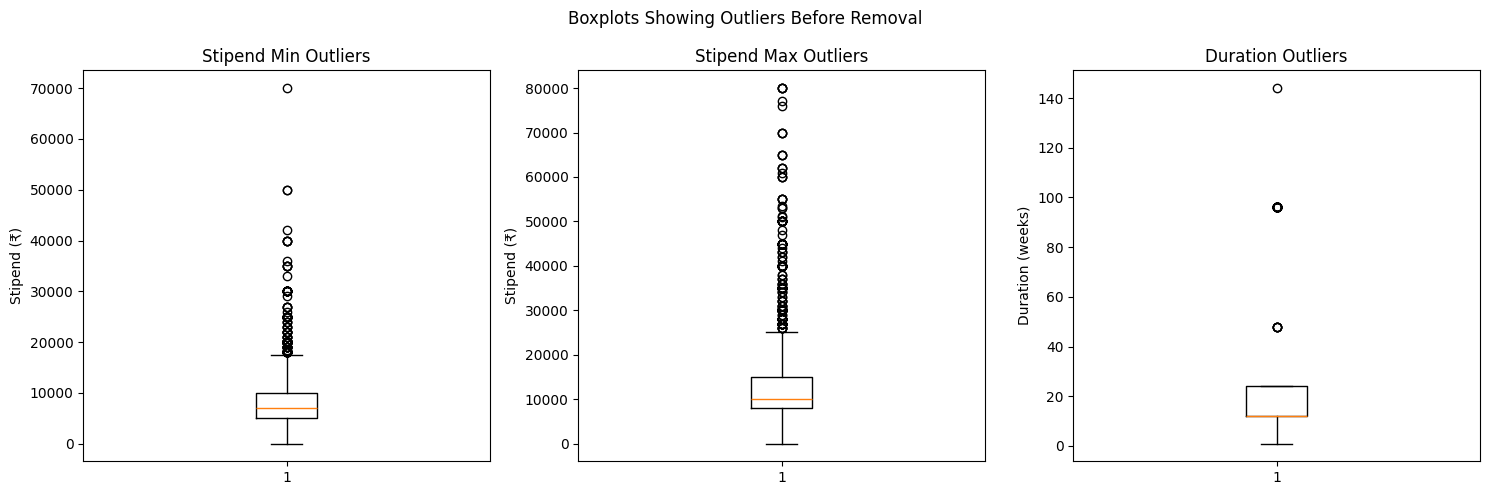

In [28]:
# visualizing outliers before removal to understand the spread
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(df["stipend_min"].dropna())
axes[0].set_title("Stipend Min Outliers")
axes[0].set_ylabel("Stipend (₹)")

axes[1].boxplot(df["stipend_max"].dropna())
axes[1].set_title("Stipend Max Outliers")
axes[1].set_ylabel("Stipend (₹)")

axes[2].boxplot(df["duration_weeks"].dropna())
axes[2].set_title("Duration Outliers")
axes[2].set_ylabel("Duration (weeks)")

plt.suptitle("Boxplots Showing Outliers Before Removal")
plt.tight_layout()
plt.show()

Why this plot was used:
- Boxplots were used to identify extreme values in selected numerical variables.

**Observations:**
- stipend_min has outliers going up to ₹70,000 — way above normal range
- stipend_max has outliers going up to ₹80,000 — even higher extreme values
- duration has outliers at 48, 96 and 144 weeks (1-3 years) — unrealistic for internships
- most data sits below ₹20,000 for stipend and below 24 weeks for duration
- IQR method will be used to remove these extreme values

In [29]:
# finding outliers using IQR method

# stipend_min outliers
Q1_s = df["stipend_min"].quantile(0.25)
Q3_s = df["stipend_min"].quantile(0.75)
IQR_s = Q3_s - Q1_s
lower_s = Q1_s - 1.5 * IQR_s      # lower bound
upper_s = Q3_s + 1.5 * IQR_s      # upper bound
print("Stipend min bounds:", lower_s, upper_s)
print("Stipend min outliers:", df[(df["stipend_min"] < lower_s) | (df["stipend_min"] > upper_s)].shape[0])

# stipend_max outliers
Q1_x = df["stipend_max"].quantile(0.25)
Q3_x = df["stipend_max"].quantile(0.75)
IQR_x = Q3_x - Q1_x
lower_x = Q1_x - 1.5 * IQR_x      # lower bound
upper_x = Q3_x + 1.5 * IQR_x      # upper bound
print("Stipend max bounds:", lower_x, upper_x)
print("Stipend max outliers:", df[(df["stipend_max"] < lower_x) | (df["stipend_max"] > upper_x)].shape[0])

# duration outliers
Q1_d = df["duration_weeks"].quantile(0.25)
Q3_d = df["duration_weeks"].quantile(0.75)
IQR_d = Q3_d - Q1_d
lower_d = Q1_d - 1.5 * IQR_d      # lower bound
upper_d = Q3_d + 1.5 * IQR_d      # upper bound
print("Duration bounds:", lower_d, upper_d)
print("Duration outliers:", df[(df["duration_weeks"] < lower_d) | (df["duration_weeks"] > upper_d)].shape[0])

Stipend min bounds: -2500.0 17500.0
Stipend min outliers: 246
Stipend max bounds: -2500.0 25500.0
Stipend max outliers: 260
Duration bounds: -6.0 42.0
Duration outliers: 44


In [30]:
# removing outliers from all three columns
df = df[(df["stipend_min"] >= lower_s) & (df["stipend_min"] <= upper_s)]
df = df[(df["stipend_max"] >= lower_x) & (df["stipend_max"] <= upper_x)]
df = df[(df["duration_weeks"] >= lower_d) & (df["duration_weeks"] <= upper_d)]

print(df.shape)   # confirm rows after outlier removal

(4417, 9)


**Observations:**
- Outliers detected using IQR method to handle skewed stipend and duration values
- Removing extreme values improves reliability of statistical analysis
- Some high-paying internships may be removed as outliers, which is a trade-off

## EDA

### 1. Univariate Analysis

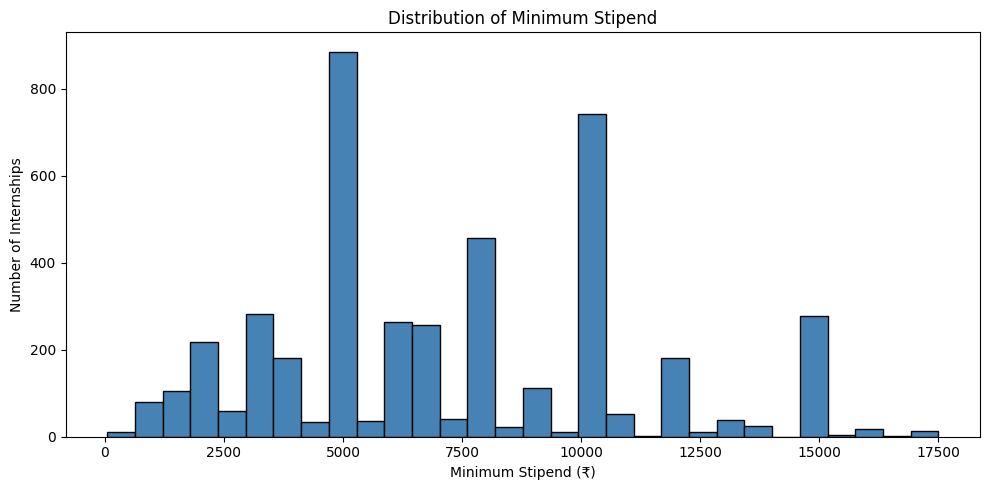

In [31]:
# Plot 1 — Histogram: Stipend Min Distribution
plt.figure(figsize=(10, 5))
plt.hist(df["stipend_min"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Minimum Stipend")
plt.xlabel("Minimum Stipend (₹)")
plt.ylabel("Number of Internships")
plt.tight_layout()
plt.show()

**Why Histogram?**
- Histogram is used to show the frequency distribution of a continuous numerical variable.
It helps understand how minimum stipend values are spread across all internships.

**Observations:**
- two major peaks at ₹5000 and ₹10000 — most common minimum stipend values
- majority of internships offer minimum stipend between ₹5000 and ₹10000
- very few internships offer above ₹15000 as minimum stipend
- distribution is not smooth, internships are posted at fixed round number stipends

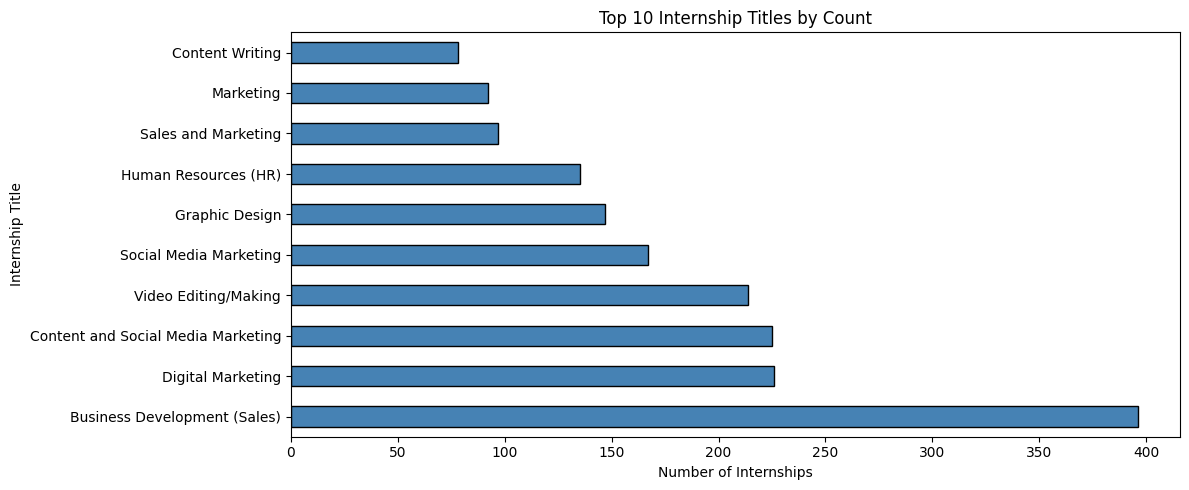

In [32]:
# Plot 2 — Bar Chart: Top 10 Internship Titles by Count
plt.figure(figsize=(12, 5))
df["internship_title"].value_counts().head(10).plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Top 10 Internship Titles by Count")
plt.xlabel("Number of Internships")
plt.ylabel("Internship Title")
plt.tight_layout()
plt.show()

**Why Bar Chart?**
- Bar chart is used to compare counts across different categories.
- It helps identify which internship roles are most frequently posted on Internshala.

**Observations:**
- Business Development (Sales) is the most posted role by a large margin
- Digital Marketing, Content and Social Media Marketing roles dominate the top 10
- all top 10 roles are Non-IT, confirming non-technical internships are more common

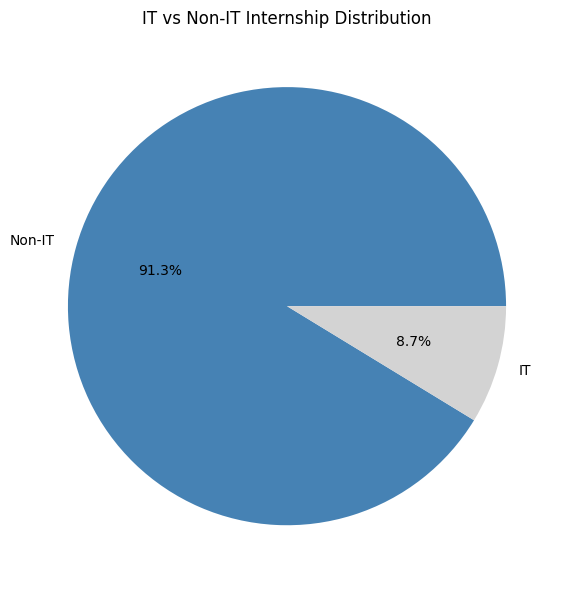

In [33]:
# Plot 3 — Pie Chart: IT vs Non-IT Distribution
plt.figure(figsize=(6, 6))
df["is_it"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["steelblue", "lightgray"], labels=["Non-IT", "IT"])
plt.title("IT vs Non-IT Internship Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Why Pie Chart?**
- Pie chart is used to show proportion of two or more categories in a whole.
- It helps understand what percentage of internships are IT vs Non-IT.

**Observations:**
- 91.2% of internships are Non-IT — overwhelming majority
- only 8.8% are IT internships
- Internshala is heavily dominated by sales, marketing and creative roles

### 2. Bivariate Analysis

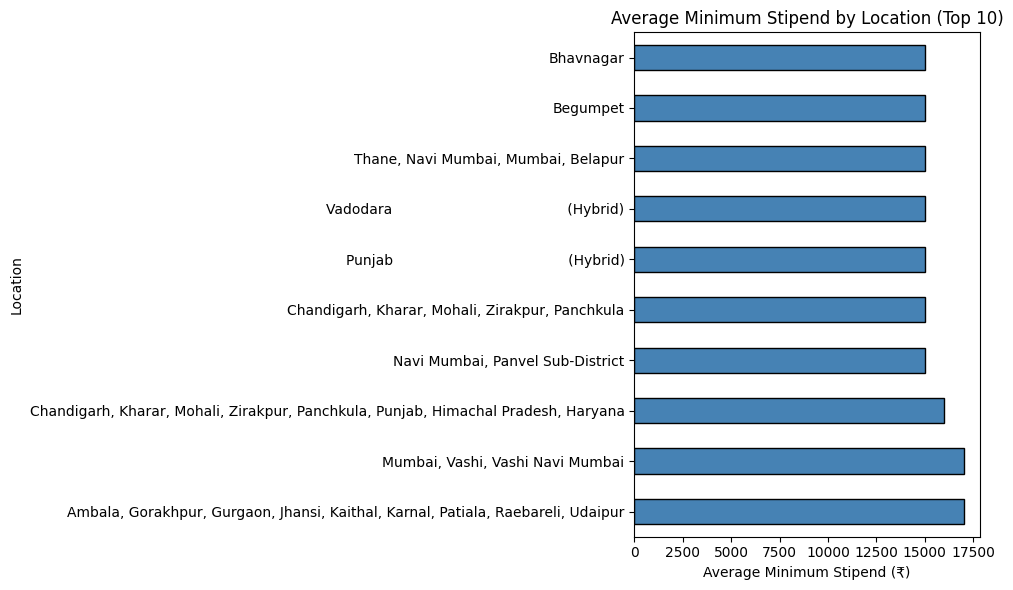

In [34]:
# Plot 4 — Horizontal Bar: Average Stipend Min by Location (Top 10)
top_locations = df.groupby("location")["stipend_min"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_locations.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Average Minimum Stipend by Location (Top 10)")
plt.xlabel("Average Minimum Stipend (₹)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

**Why Horizontal Bar Chart?**
- Horizontal bar chart is used when category names are long — easier to read than vertical bars.
- It helps compare average minimum stipend across different locations.

**Observations:**
- top paying locations are mostly multi-city or specific area listings
- Ambala, Gorakhpur combined listing pays highest average minimum stipend
- single well known cities like Mumbai and Bangalore don't appear in top 10 alone
- multi-city listings skew the location based stipend analysis

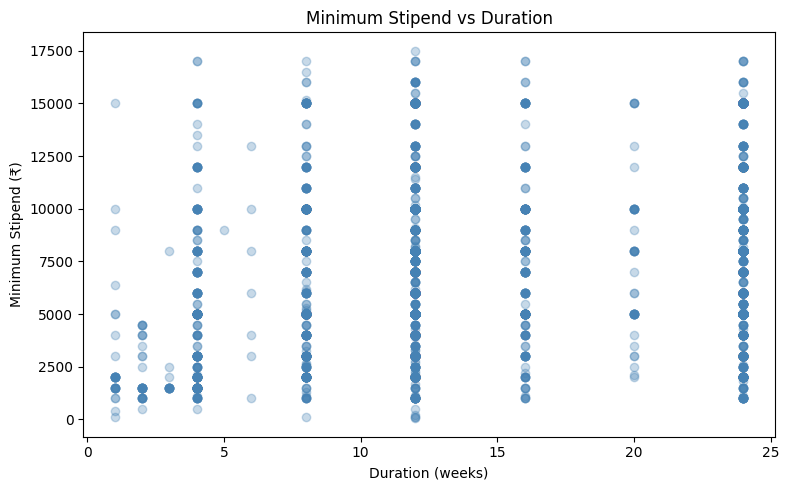

In [35]:
# Plot 5 — Scatter Plot: Stipend Min vs Duration Weeks
plt.figure(figsize=(8, 5))
plt.scatter(df["duration_weeks"], df["stipend_min"], alpha=0.3, color="steelblue")
plt.title("Minimum Stipend vs Duration")
plt.xlabel("Duration (weeks)")
plt.ylabel("Minimum Stipend (₹)")
plt.tight_layout()
plt.show()

**Why Scatter Plot?**
- Scatter plot is used to show relationship between two continuous numerical variables.
- It helps understand if longer internships tend to pay more.

**Observations:**
- no clear linear relationship between duration and minimum stipend
- internships cluster at fixed durations like 4, 8, 12, 16, 24 weeks
- stipend varies widely at every duration level
- duration alone does not determine pay

<Figure size 600x500 with 0 Axes>

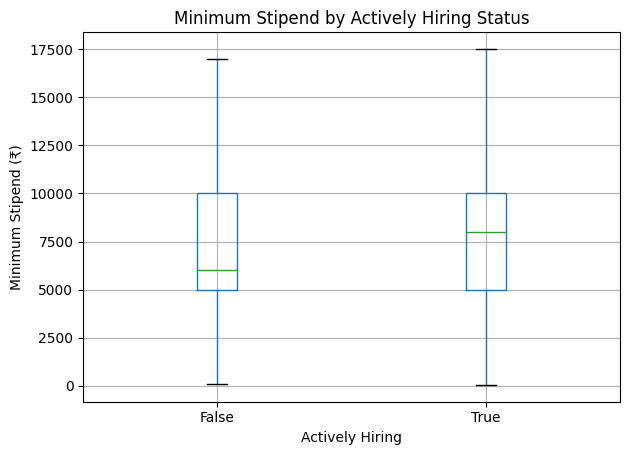

In [36]:
# Plot 6 — Boxplot: Stipend Min by Actively Hiring
plt.figure(figsize=(6, 5))
df.boxplot(column="stipend_min", by="actively_hiring")
plt.title("Minimum Stipend by Actively Hiring Status")
plt.suptitle("")
plt.xlabel("Actively Hiring")
plt.ylabel("Minimum Stipend (₹)")
plt.tight_layout()
plt.show()

**Why Boxplot?**
- Boxplot is used to compare distribution of a numerical variable across categories.
- It helps understand if actively hiring internships offer better stipends.

**Observations:**
- both actively hiring and non actively hiring internships show similar median stipend around ₹6000-₹8000
- spread is similar for both groups
- actively hiring status has no significant impact on stipend offered

### 3. Multivariate Analysis

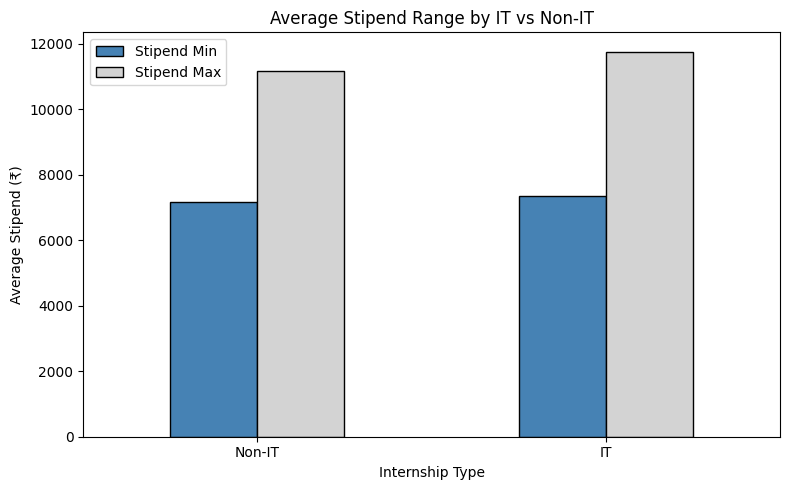

In [37]:
# Plot 7 — Grouped Bar: Average Stipend Min and Max by IT vs Non-IT
it_stipend = df.groupby("is_it")[["stipend_min", "stipend_max"]].mean()
it_stipend.index = ["Non-IT", "IT"]

it_stipend.plot(kind="bar", figsize=(8, 5), color=["steelblue", "lightgray"], edgecolor="black")
plt.title("Average Stipend Range by IT vs Non-IT")
plt.xlabel("Internship Type")
plt.ylabel("Average Stipend (₹)")
plt.xticks(rotation=0)
plt.legend(["Stipend Min", "Stipend Max"])
plt.tight_layout()
plt.show()

**Why Grouped Bar Chart?**
- Grouped bar chart is used to compare multiple numerical values across categories side by side.
- It helps compare both minimum and maximum stipend between IT and Non-IT internships.

**Observations:**
- IT internships offer slightly higher minimum and maximum stipend than Non-IT
- the difference is not dramatic — average minimum is ₹7400 IT vs ₹7200 Non-IT
- maximum stipend gap is larger — IT reaches ₹11700 vs Non-IT ₹11100
- IT roles have a wider pay range overall

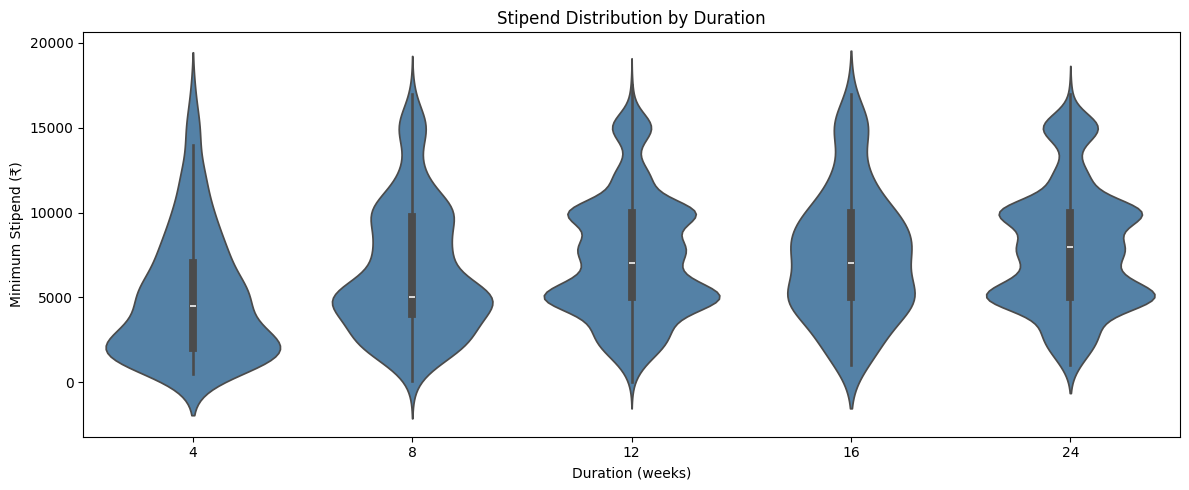

In [38]:
# Plot 8 — Violin Plot: Stipend Min by Duration Weeks
plt.figure(figsize=(12, 5))
df_violin = df[df["duration_weeks"].isin([4, 8, 12, 16, 24])]   # top 5 most common durations
sns.violinplot(x="duration_weeks", y="stipend_min", data=df_violin, color="steelblue")
plt.title("Stipend Distribution by Duration")
plt.xlabel("Duration (weeks)")
plt.ylabel("Minimum Stipend (₹)")
plt.tight_layout()
plt.show()

**Why Violin Plot?**
- Violin plot combines boxplot and distribution plot — shows both spread and shape of data.
- It helps compare stipend distribution across the most common internship durations.

**Observations:**
- all durations show similar median stipend around ₹5000-₹8000
- 16 and 24 week internships show wider distribution — more variety in pay
- 4 week internships are narrower at the bottom — fewer high paying short internships
- duration does not strongly determine stipend amount

### 4. Pivot Table Analysis

In [39]:
# pivot table showing average stipend_min by is_it and duration_weeks
pivot = df.pivot_table(values="stipend_min", index="duration_weeks", columns="is_it", aggfunc="mean")
pivot.columns = ["Non-IT", "IT"]
print(pivot)

                     Non-IT           IT
duration_weeks                          
1               3145.833333  2390.000000
2               2066.666667  2200.000000
3               2071.428571  1500.000000
4               4978.378378  5264.705882
5               9000.000000          NaN
6               6428.571429          NaN
8               6396.821809  7294.088235
12              7256.064000  7430.676056
16              7473.253521  7272.727273
20              7536.560976  7525.000000
24              7758.100744  8357.645833


**Why Pivot Table?**
- Pivot table summarizes data by grouping two categorical/discrete variables and calculating aggregate values.
- It helps compare average minimum stipend across duration and IT vs Non-IT simultaneously.

**Observations:**
- IT internships consistently pay higher than Non-IT across all durations
- longer durations generally show slightly higher stipend for IT roles
- Non-IT stipend remains relatively flat regardless of duration

### 5. Pivot Table Heatmap

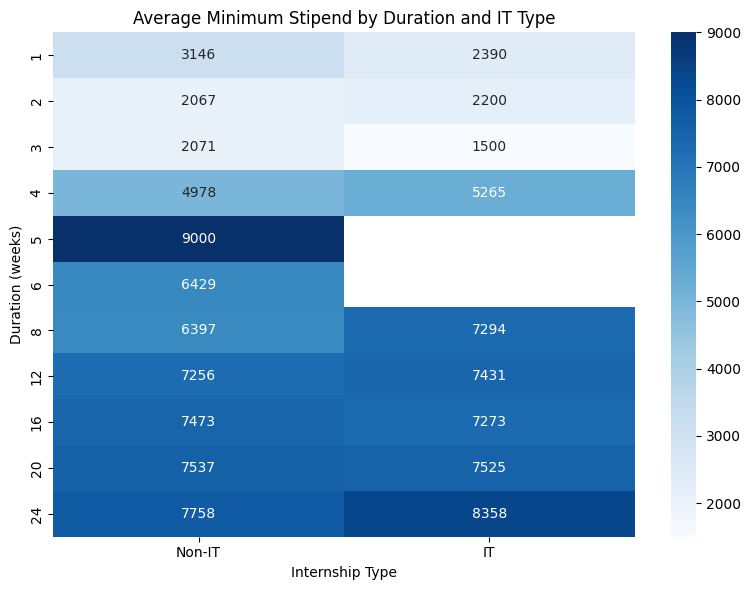

In [40]:
# heatmap of pivot table for visual comparison
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Average Minimum Stipend by Duration and IT Type")
plt.xlabel("Internship Type")
plt.ylabel("Duration (weeks)")
plt.tight_layout()
plt.show()

**Why Heatmap?**
- Heatmap gives a colour coded visual of the pivot table — easier to spot patterns than reading numbers.
- Darker colour means higher stipend value.

**Observations:**
- IT internships at 24 weeks show highest average minimum stipend of ₹8305
- Non-IT at 5 weeks shows unusually high ₹9000 — likely very few listings skewing the average
- IT internships are consistently darker (higher pay) than Non-IT at longer durations
- 1, 2, 3 week internships are lightest — lowest paying regardless of IT or Non-IT

## Conclusion

Based on the analysis of internship data scraped from Internshala:

- Business Development (Sales) is the most posted role, followed by Digital Marketing and Content roles
- Non-IT internships dominate the platform — IT roles are a smaller portion of total listings
- Most internships offer minimum stipend between ₹5000 and ₹10000
- IT internships consistently pay higher than Non-IT across all durations and locations
- Duration and actively hiring status have weak effect on stipend amount
- Work from home is the most common internship format across India

Answering our core question — what factors affect internship stipend:
- Role type (IT vs Non-IT) matters most — IT roles pay significantly higher
- Location has weak impact due to multi-city listings skewing the results
- Duration alone does not determine pay — stipend varies widely at all durations
- Actively hiring status has minimal effect on stipend offered